# El precio oculto de la fauna en Europa

Un lince ibérico vale **€93.884** para la ley española. Un caracol vale **€82**. Y la diferencia entre ambos no tiene que ver con lo amenazados que están.

**Paper:** *Hidden patterns in fauna compensation values in European biodiversity legislation* — Nature Ecology & Evolution, 2026.
**DOI:** [10.1038/s41559-026-03067-5](https://doi.org/10.1038/s41559-026-03067-5)
**Datos:** [Figshare repository](https://doi.org/10.6084/m9.figshare.30031285) (CC BY 4.0)

[![Abrir en Colab](https://colab.research.google.com/papers/2026-05-13-precio-fauna-europa)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-13-precio-fauna-europa/notebook.ipynb)
*Video Short:* [Ver en YouTube](https://youtube.com/shorts/j732Mq4OYJw)

## ¿Qué estamos mirando?

Varios países europeos usan **listas oficiales de precios por especie** para calcular cuánto cuesta una infracción contra la fauna. Cazar un oso ilegalmente tiene un precio. Atropellar un erizo, otro. Esos precios deciden multas y compensaciones reales.

La pregunta del paper: ¿qué decide ese precio? El equipo cruzó **9.971 registros** (especie-país) en **24 países europeos** y miró si los precios respondían a criterios ecológicos coherentes — o a otra cosa.

Vamos a abrir los datos y ver el patrón.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
RATIO_MAM_OTROS = 7.1        # cuántas veces más cara la mediana de mamíferos vs "otros"
RATIO_AVES_OTROS = 3.7       # cuántas veces más cara la mediana de aves vs "otros"
N_REGISTROS = 9971           # entradas species-país (NO especies únicas)
N_ESPECIES_UNICAS = 3031
N_PAISES = 24
FUENTE = 'Fuente: Hidden patterns in fauna compensation values (Nature Ecol & Evol, 2026) | Datos: Figshare DOI 10.6084/m9.figshare.30031285'

COLOR_MAMIFEROS = '#DC2626'   # rojo — el grupo que dispara
COLOR_AVES = '#D97706'        # ámbar — el otro grupo que dispara
COLOR_OTROS = '#2563EB'       # azul CaM — el resto
COLOR_REFERENCIA = '#7C3AED'  # violeta — outliers o líneas guía
COLOR_NEUTRO = '#BBBBBB'

# Imports
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file,
        )
plt.style.use(style_file)

# Cargar los 5 datasets pre-agregados (cálculos hechos a partir del Dataset.xlsx de Figshare)
DATA_DIR = 'datos'
clase = pd.read_csv(f'{DATA_DIR}/precio_por_clase.csv')
pais = pd.read_csv(f'{DATA_DIR}/precio_por_pais.csv')
iucn = pd.read_csv(f'{DATA_DIR}/precio_por_iucn.csv')
generacion = pd.read_csv(f'{DATA_DIR}/precio_por_generacion.csv')
masa = pd.read_csv(f'{DATA_DIR}/precio_vs_masa.csv')

print(f'Registros species-país: {N_REGISTROS:,}'.replace(',', '.'))
print(f'Especies únicas:        {N_ESPECIES_UNICAS:,}'.replace(',', '.'))
print(f'Países europeos:        {N_PAISES}')
print(f'Clases taxonómicas:     {clase.shape[0]}')
print()
print(f'Mediana global:         €{194.66:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f'Precio máximo:          €{190171.12:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'), '(leopardo en Armenia)')

Registros species-país: 9.971
Especies únicas:        3.031
Países europeos:        24
Clases taxonómicas:     16

Mediana global:         €194,66
Precio máximo:          €190.171,12 (leopardo en Armenia)


## Aquí está.

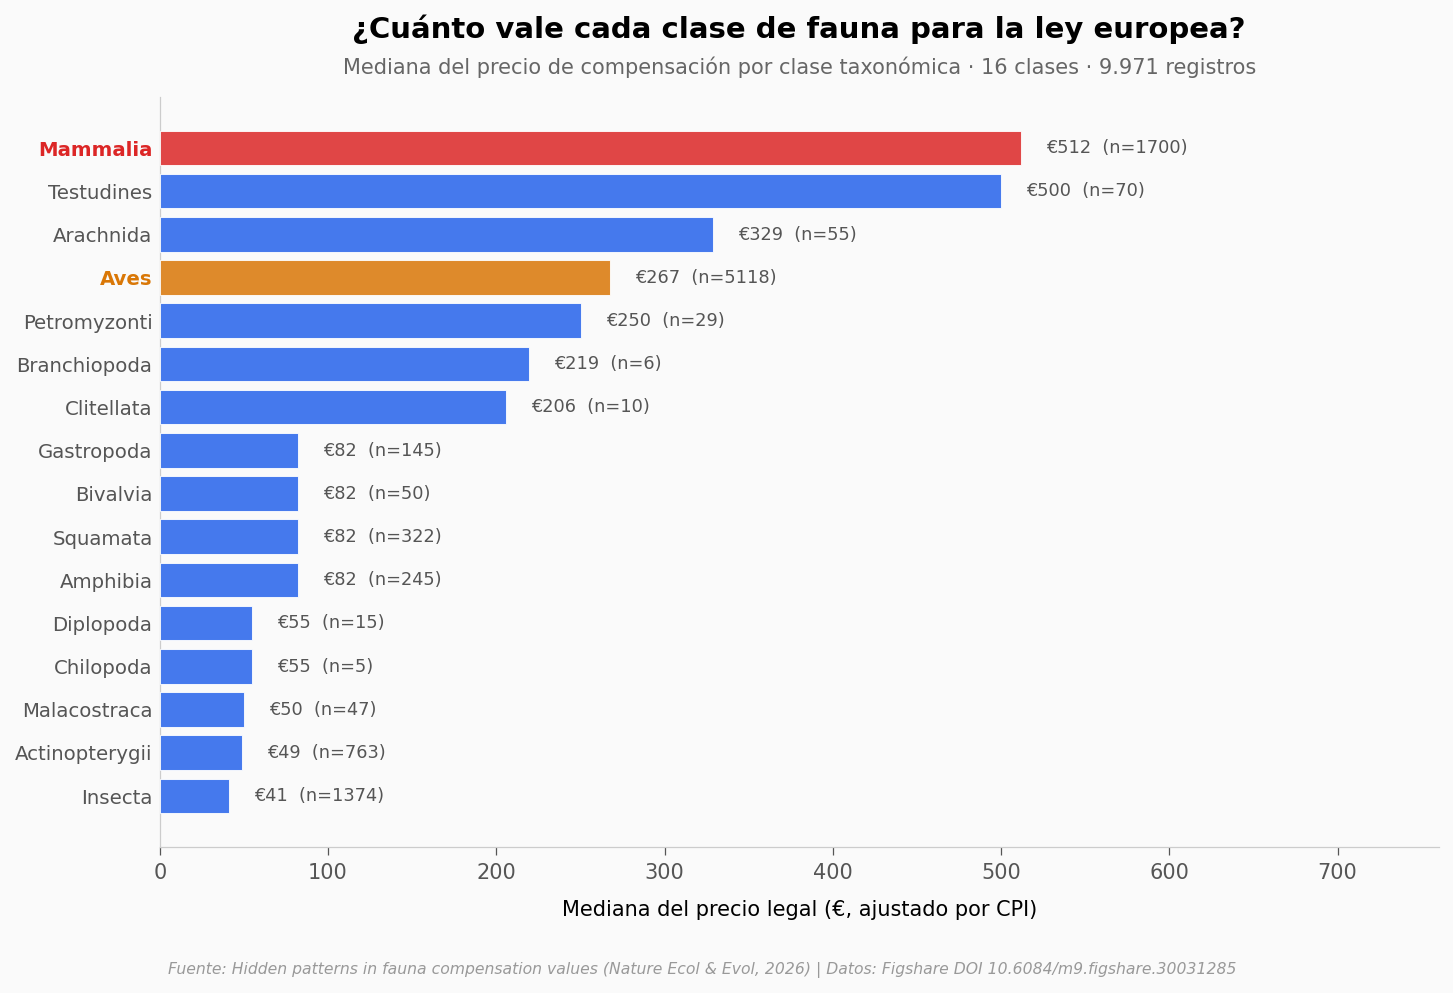

In [2]:
# Ordenar por mediana descendente para que la jerarquía sea obvia
clase_ord = clase.sort_values('median_eur', ascending=True).reset_index(drop=True)

# Definir grupos del paper: mamíferos | aves | resto
def color_grupo(c):
    if c == 'Mammalia': return COLOR_MAMIFEROS
    if c == 'Aves':     return COLOR_AVES
    return COLOR_OTROS

colores = [color_grupo(c) for c in clase_ord['class']]

fig, ax = plt.subplots(figsize=(11, 6.5))
y_pos = np.arange(len(clase_ord))

# Barra horizontal: mediana
ax.barh(y_pos, clase_ord['median_eur'], color=colores, alpha=0.85,
        edgecolor='white', linewidth=0.5, zorder=3)

# Etiquetas con valor a la derecha de cada barra
for i, (med, n) in enumerate(zip(clase_ord['median_eur'], clase_ord['n'])):
    ax.text(med + 15, i, f'€{med:.0f}  (n={n})', va='center', fontsize=8.5,
            color='#555555')

ax.set_yticks(y_pos)
# Colorear los nombres de clases que el paper destaca (mamíferos rojo, aves ámbar)
ax.set_yticklabels(clase_ord['class'], fontsize=9.5)
for tick_label, cl in zip(ax.get_yticklabels(), clase_ord['class']):
    if cl == 'Mammalia':
        tick_label.set_color(COLOR_MAMIFEROS)
        tick_label.set_fontweight('bold')
    elif cl == 'Aves':
        tick_label.set_color(COLOR_AVES)
        tick_label.set_fontweight('bold')
ax.set_xlabel('Mediana del precio legal (€, ajustado por CPI)', fontsize=10)
ax.set_xlim(0, 760)

ax.set_title('¿Cuánto vale cada clase de fauna para la ley europea?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Mediana del precio de compensación por clase taxonómica · 16 clases · 9.971 registros',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.grid(False, axis='y')
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')

plt.savefig('figuras/precio_por_clase.png', dpi=200, bbox_inches='tight')
plt.show()

La jerarquía no es sutil. La mediana de mamíferos (€511) está **7,1 veces** por encima de la mediana del resto de fauna (€72). Las aves (€267) van **3,7 veces** por encima.

Insectos, gasterópodos, bivalvos — toda la base de los ecosistemas — se aplastan abajo, entre €41 y €82. El test de Mann-Whitney da p ≈ 10⁻²³³ para mamíferos vs resto, y p ≈ 10⁻²⁶¹ para aves vs resto. La diferencia no es ruido.

## ¿Y entre países?

Los precios son nacionales — cada legislación pone los suyos. Si los criterios fueran ecológicos uniformes, esperaríamos algo de variación, sí, pero no un orden de magnitud.

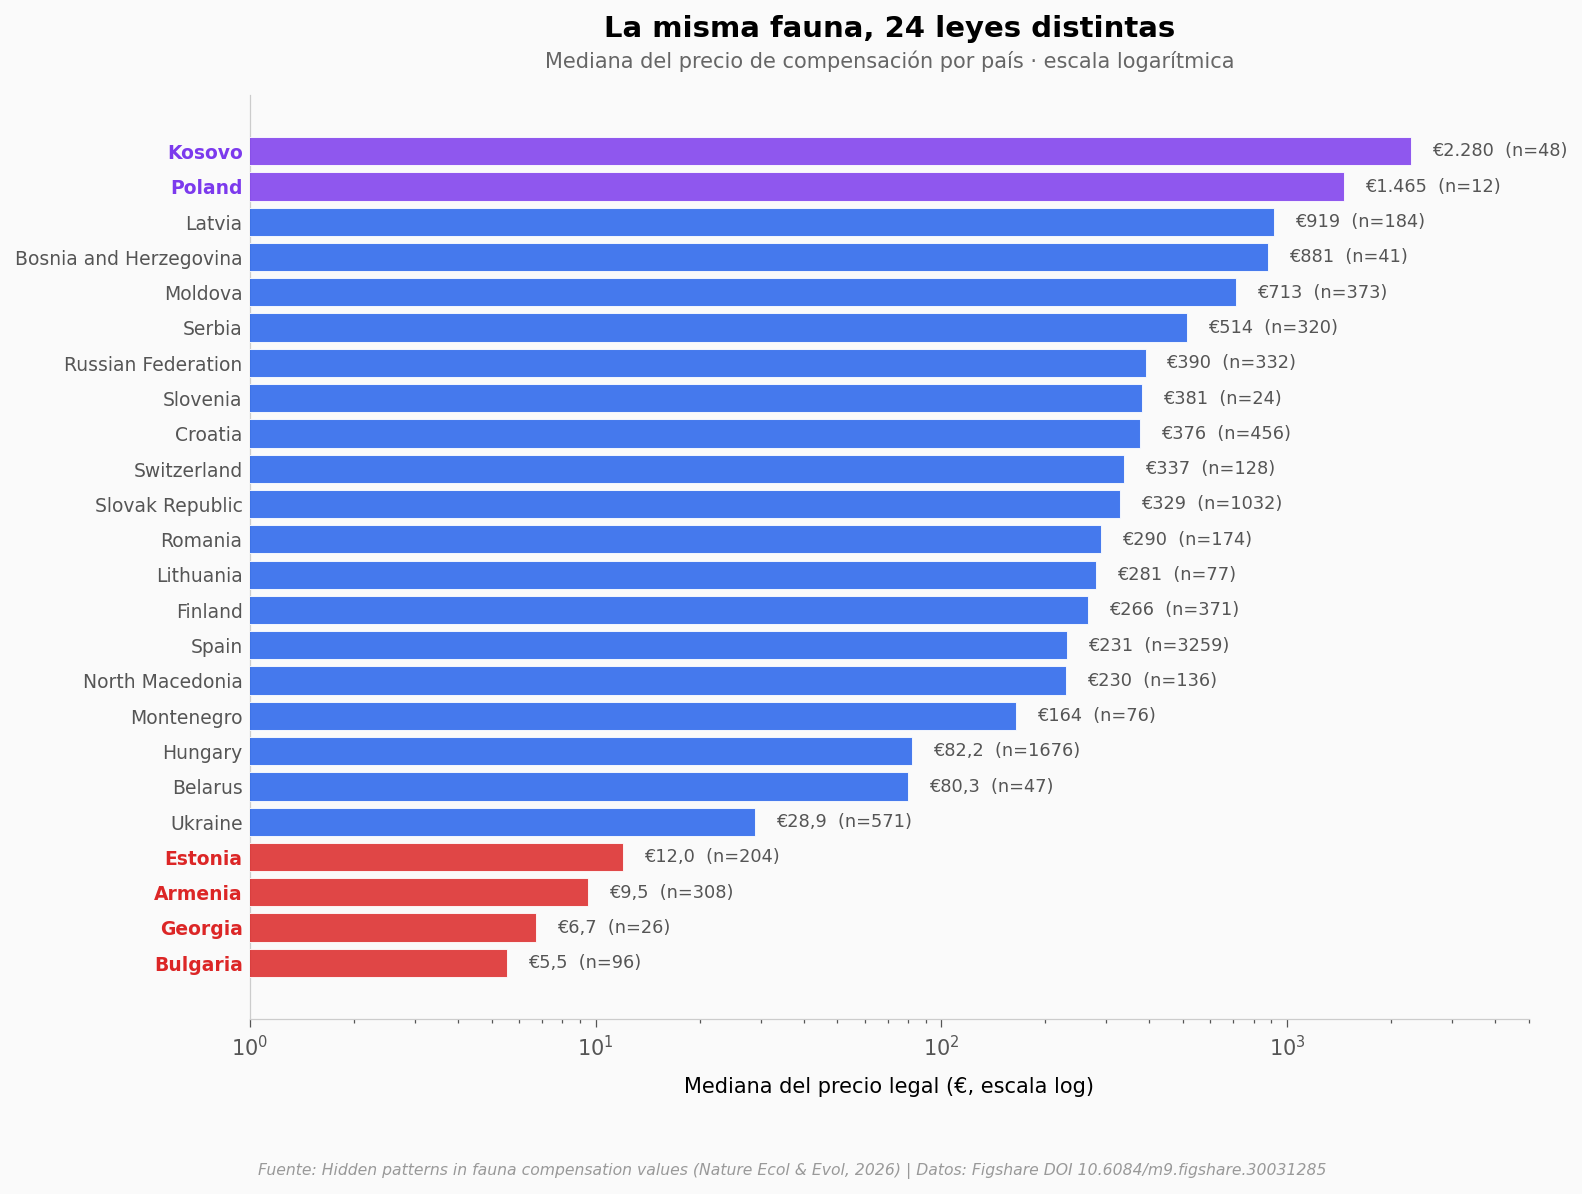

In [3]:
# Ordenar países por mediana descendente
pais_ord = pais.sort_values('median_eur', ascending=True).reset_index(drop=True)

# Resaltar extremos
def color_pais(country):
    if country in ('Kosovo', 'Poland'):
        return COLOR_REFERENCIA
    if country in ('Bulgaria', 'Georgia', 'Armenia', 'Estonia'):
        return COLOR_MAMIFEROS
    return COLOR_OTROS

colores_pais = [color_pais(c) for c in pais_ord['country']]

fig, ax = plt.subplots(figsize=(11, 8))
y_pos = np.arange(len(pais_ord))

ax.barh(y_pos, pais_ord['median_eur'], color=colores_pais, alpha=0.85,
        edgecolor='white', linewidth=0.5, zorder=3)

# Eje logarítmico — los rangos van de €5 a €2.279
ax.set_xscale('log')
ax.set_xlim(1, 5000)

# Etiqueta de valor a la derecha
for i, (med, n) in enumerate(zip(pais_ord['median_eur'], pais_ord['n'])):
    med_str = f'€{med:,.0f}'.replace(',', '.') if med >= 100 else f'€{med:.1f}'.replace('.', ',')
    ax.text(med * 1.15, i, f'{med_str}  (n={n})', va='center', fontsize=8.5,
            color='#555555')

ax.set_yticks(y_pos)
ax.set_yticklabels(pais_ord['country'], fontsize=9)
ax.set_xlabel('Mediana del precio legal (€, escala log)', fontsize=10)

ax.set_title('La misma fauna, 24 leyes distintas',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Mediana del precio de compensación por país · escala logarítmica',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Colorear yticklabels de los extremos
extremos_alto = {'Kosovo', 'Poland'}
extremos_bajo = {'Bulgaria', 'Georgia', 'Armenia', 'Estonia'}
for tick_label, country in zip(ax.get_yticklabels(), pais_ord['country']):
    if country in extremos_alto:
        tick_label.set_color(COLOR_REFERENCIA)
        tick_label.set_fontweight('bold')
    elif country in extremos_bajo:
        tick_label.set_color(COLOR_MAMIFEROS)
        tick_label.set_fontweight('bold')

ax.grid(False, axis='y')
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')

plt.savefig('figuras/precio_por_pais.png', dpi=200, bbox_inches='tight')
plt.show()

Entre el techo de Kosovo y el suelo de Bulgaria hay **un factor de 411**. La misma legislación europea, las mismas especies, precios que no se reconocen entre sí.

## ¿Y el riesgo de extinción decide algo?

Aquí esperaríamos lo obvio: cuanto más amenazada una especie, más alto su precio. Veamos qué dicen los datos.

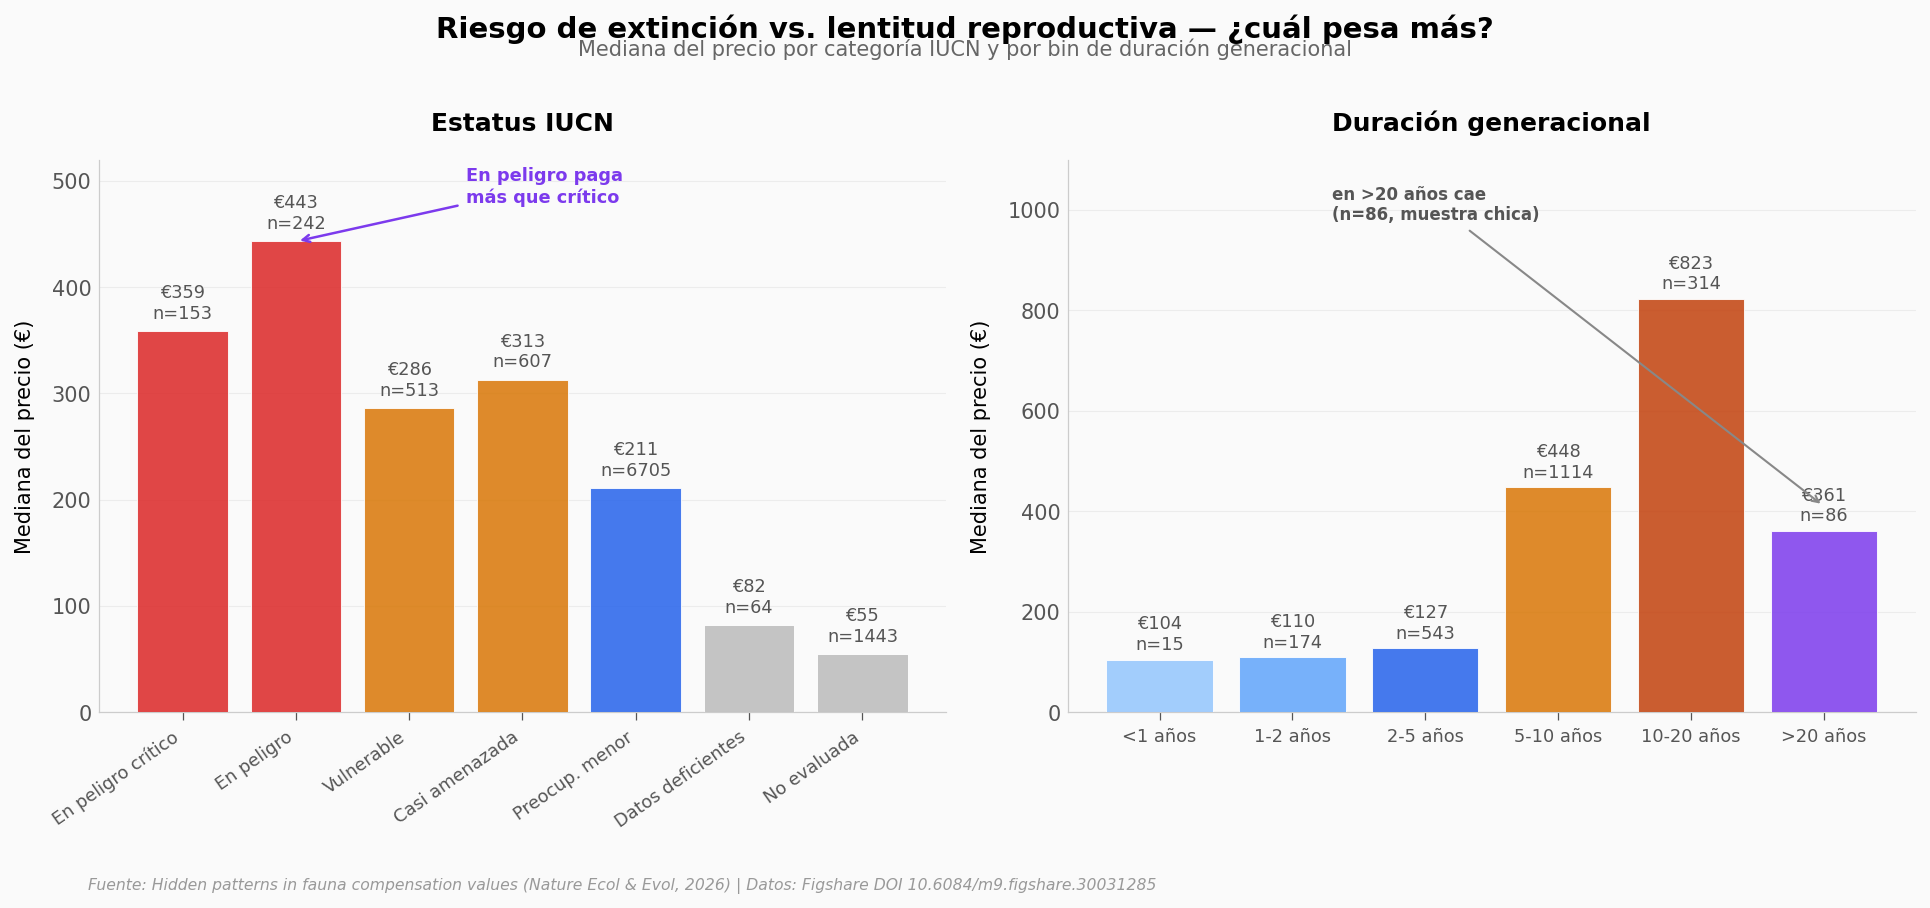

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Panel izquierdo: IUCN ────────────────────────────────────
iucn_order = ['CR', 'EN', 'VU', 'NT', 'LC', 'DD', 'NE']
iucn_labels = {
    'CR': 'En peligro crítico',
    'EN': 'En peligro',
    'VU': 'Vulnerable',
    'NT': 'Casi amenazada',
    'LC': 'Preocup. menor',
    'DD': 'Datos deficientes',
    'NE': 'No evaluada',
}
iucn_plot = iucn.set_index('iucn_category').loc[iucn_order].reset_index()

# Colores: gradiente rojo→azul para amenaza, gris para DD/NE
iucn_colors = [COLOR_MAMIFEROS, COLOR_MAMIFEROS, COLOR_AVES, COLOR_AVES,
               COLOR_OTROS, COLOR_NEUTRO, COLOR_NEUTRO]
alphas = [0.95, 0.85, 0.75, 0.65, 0.55, 0.5, 0.5]

bars = ax1.bar(range(len(iucn_plot)), iucn_plot['median_eur'],
               color=iucn_colors, alpha=0.85, edgecolor='white', linewidth=0.5, zorder=3)

for bar, med, n in zip(bars, iucn_plot['median_eur'], iucn_plot['n']):
    ax1.text(bar.get_x() + bar.get_width()/2, med + 12,
             f'€{med:.0f}\nn={n}', ha='center', fontsize=8.5, color='#555555')

ax1.set_xticks(range(len(iucn_plot)))
ax1.set_xticklabels([iucn_labels[c] for c in iucn_plot['iucn_category']],
                    rotation=35, ha='right', fontsize=8.5)
ax1.set_ylabel('Mediana del precio (€)', fontsize=10)
ax1.set_ylim(0, 520)
ax1.set_title('Estatus IUCN', fontsize=12, fontweight='bold', pad=14)

# Anotación: EN > CR (no monotónico)
ax1.annotate('En peligro paga\nmás que crítico',
             xy=(1, 443), xytext=(2.5, 480),
             fontsize=8.5, color=COLOR_REFERENCIA, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.2))

# ── Panel derecho: generación ────────────────────────────────
gen_order = ['<1', '1-2', '2-5', '5-10', '10-20', '>20']
gen_plot = generacion.set_index('generacion_anios').loc[gen_order].reset_index()

# Gradiente azul → ámbar para visualizar el aumento
gen_colors = ['#93C5FD', '#60A5FA', '#2563EB', '#D97706', '#C2410C', '#7C3AED']
bars2 = ax2.bar(range(len(gen_plot)), gen_plot['median_eur'],
                color=gen_colors, alpha=0.85, edgecolor='white', linewidth=0.5, zorder=3)

for bar, med, n in zip(bars2, gen_plot['median_eur'], gen_plot['n']):
    ax2.text(bar.get_x() + bar.get_width()/2, med + 20,
             f'€{med:.0f}\nn={n}', ha='center', fontsize=8.5, color='#555555')

ax2.set_xticks(range(len(gen_plot)))
ax2.set_xticklabels([f'{g} años' for g in gen_plot['generacion_anios']],
                    fontsize=8.5)
ax2.set_ylabel('Mediana del precio (€)', fontsize=10)
ax2.set_ylim(0, 1100)
ax2.set_title('Duración generacional', fontsize=12, fontweight='bold', pad=14)

# Anotación: el bin >20 cae (movida arriba a la izquierda para no solapar)
ax2.annotate('en >20 años cae\n(n=86, muestra chica)',
             xy=(5, 410), xytext=(1.3, 980),
             fontsize=8, color='#555555', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#888888', lw=1.0))

fig.suptitle('Riesgo de extinción vs. lentitud reproductiva — ¿cuál pesa más?',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, 0.97, 'Mediana del precio por categoría IUCN y por bin de duración generacional',
         fontsize=10, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.05, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')

plt.savefig('figuras/iucn_generacion.png', dpi=200, bbox_inches='tight')
plt.show()

Aquí pasan dos cosas que vale la pena nombrar:

1. **El estatus IUCN influye, pero no manda.** Las especies *En peligro* (€443) reciben **más** que las *En peligro crítico* (€358). Si el criterio fuera puramente conservacionista, el orden tendría que ser estricto. No lo es.
2. **La duración generacional sí ordena casi monotónicamente.** Especies que tardan 10-20 años entre generaciones cobran €823 — ocho veces más que las que renuevan generaciones en un año. Es la correlación más fuerte del estudio: el paper reporta ρ de Spearman = 0,36 (n=2.246, p ≈ 10⁻⁷⁰) sobre el dataset completo. Cuando la recalculamos abajo sobre el subconjunto con `gen_length` que tenemos a mano (n=1.682), da ρ = 0,43 — coherente con la dirección, un poco más alta porque el subset es más estrecho.

¿Y la longevidad máxima? Correlación **negativa** y débil (ρ = −0,089). Lo señalamos porque va contra la intuición — vivir muchos años no encarece el precio legal.

## Lo que esto significa en magnitud

Veamos cómo se distribuyen las **9.971** valoraciones, y cuán lejos del centro están los outliers.

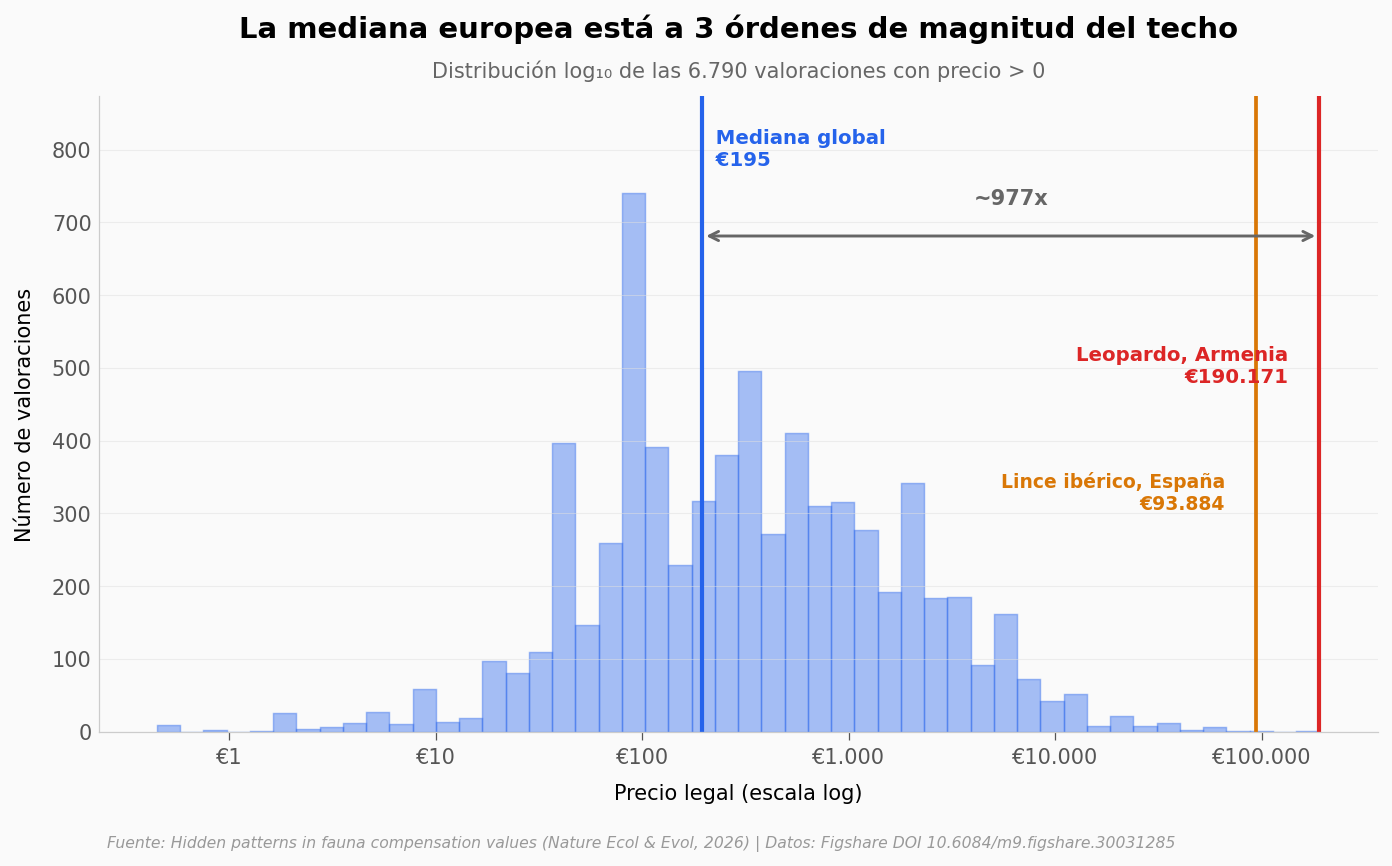

Correlaciones (Spearman sobre log-log):
  log(precio) vs log(masa corporal):     ρ = +0.236  (n=6790, p ≈ 1.7e-86)
  log(precio) vs log(duración gen.):     ρ = +0.428  (n=1682, p ≈ 6.1e-76)


In [5]:
# Quitar ceros y NA, log10 para visualizar 5 órdenes de magnitud
prices = masa['price_cpi_eur'].dropna()
prices = prices[prices > 0]
log_prices = np.log10(prices)

mediana_global = 194.66
max_record = 190171.12   # leopardo en Armenia
lince_iberico = 93883.71  # mayor para España

fig, ax = plt.subplots(figsize=(11, 5.5))

n, bins, patches = ax.hist(log_prices, bins=50, color=COLOR_OTROS, alpha=0.4,
                            edgecolor=COLOR_OTROS, linewidth=0.7)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

# Línea: mediana global
ax.axvline(x=np.log10(mediana_global), color=COLOR_OTROS, linewidth=2)
ax.text(np.log10(mediana_global), y_max * 0.95,
        f'  Mediana global\n  €{mediana_global:.0f}',
        fontsize=9.5, color=COLOR_OTROS, fontweight='bold', va='top')

# Helper para separador de miles con punto (sin afectar comas del texto)
def fmt_eur(v):
    return '€' + f'{v:,.0f}'.replace(',', '.')

# Línea: leopardo
ax.axvline(x=np.log10(max_record), color=COLOR_MAMIFEROS, linewidth=2)
ax.text(np.log10(max_record) - 0.15, y_max * 0.55,
        f'Leopardo, Armenia\n{fmt_eur(max_record)}',
        fontsize=9.5, color=COLOR_MAMIFEROS, fontweight='bold', ha='right')

# Línea: lince
ax.axvline(x=np.log10(lince_iberico), color=COLOR_AVES, linewidth=1.8)
ax.text(np.log10(lince_iberico) - 0.15, y_max * 0.35,
        f'Lince ibérico, España\n{fmt_eur(lince_iberico)}',
        fontsize=9, color=COLOR_AVES, fontweight='bold', ha='right')

# Flecha bidireccional entre mediana y leopardo
ax.annotate('', xy=(np.log10(max_record), y_max * 0.78),
            xytext=(np.log10(mediana_global), y_max * 0.78),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.4))
ax.text((np.log10(mediana_global) + np.log10(max_record))/2, y_max * 0.83,
        '~977x', ha='center', fontsize=10, color='#666666', fontweight='bold')

# Eje X en valores legibles
xticks = [0, 1, 2, 3, 4, 5]
ax.set_xticks(xticks)
ax.set_xticklabels(['€1', '€10', '€100', '€1.000', '€10.000', '€100.000'], fontsize=10)
ax.set_xlabel('Precio legal (escala log)', fontsize=10)
ax.set_ylabel('Número de valoraciones', fontsize=10)

ax.set_title('La mediana europea está a 3 órdenes de magnitud del techo',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Distribución log₁₀ de las {len(prices):,} valoraciones con precio > 0'.replace(',', '.'),
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_precios.png', dpi=200, bbox_inches='tight')
plt.show()

# Verificación de correlaciones con Spearman (ρ — no Pearson, datos no normales)
masa_clean = masa.dropna(subset=['adult_body_mass_g', 'price_cpi_eur'])
masa_clean = masa_clean[(masa_clean['adult_body_mass_g'] > 0) & (masa_clean['price_cpi_eur'] > 0)]
rho_masa, p_masa = stats.spearmanr(np.log10(masa_clean['adult_body_mass_g']),
                                    np.log10(masa_clean['price_cpi_eur']))

gen_clean = masa.dropna(subset=['gen_length_y', 'price_cpi_eur'])
gen_clean = gen_clean[(gen_clean['gen_length_y'] > 0) & (gen_clean['price_cpi_eur'] > 0)]
rho_gen, p_gen = stats.spearmanr(np.log10(gen_clean['gen_length_y']),
                                  np.log10(gen_clean['price_cpi_eur']))

print('Correlaciones (Spearman sobre log-log):')
print(f'  log(precio) vs log(masa corporal):     ρ = {rho_masa:+.3f}  (n={len(masa_clean)}, p ≈ {p_masa:.1e})')
print(f'  log(precio) vs log(duración gen.):     ρ = {rho_gen:+.3f}  (n={len(gen_clean)}, p ≈ {p_gen:.1e})')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| Mamíferos y aves reciben precios desproporcionadamente más altos | ✅ | Mediana mamíferos €511,67 (n=1.700) vs resto €72,55 (n≈3.150); ratio 7,1×. Mann-Whitney p ≈ 10⁻²³³. |
| La duración generacional influye en el precio | ✅ | Paper: ρ de Spearman = +0,36 (n=2.246, p ≈ 10⁻⁷⁰). Nuestro recálculo en el subset: ρ = +0,43 (n=1.682, p ≈ 6×10⁻⁷⁶). Es la correlación más fuerte del estudio. |
| El estatus de protección influye en el precio | ⚠️ | Los datos respaldan que NE/DD reciben menos (€55, €82). Pero la jerarquía CR→EN→VU→NT→LC **no es estrictamente monotónica**: la categoría *En peligro* (€443) supera a *En peligro crítico* (€358). El paper lo enmarca como influencia, no como gradiente. |
| Hay grandes diferencias entre países | ✅ | Mediana Kosovo €2.279,82 (n=48) vs Bulgaria €5,54 (n=96). Spread de 411× para la misma legislación europea. |
| La masa corporal correlaciona con el precio | ✅ | Spearman ρ ≈ +0,24 sobre log-log. Paper: n=7.144, p ≈ 10⁻⁹². Recalculado sobre nuestro CSV pre-agregado: n=6.790, p ≈ 10⁻⁸⁶. Efecto real, más débil que generación. |
| A más longevidad, más precio | ❌ | La correlación con longevidad máxima es **negativa y débil** (ρ = −0,089 según el paper; longevidad no está en nuestro CSV pre-agregado, así que no podemos recalcularla). Vivir muchos años no encarece el precio legal. |

> **Limitaciones.**
> - **Datos pre-agregados:** los CSVs disponibles son medianas e IQR por categoría — no recalculamos los tests sobre datos individuales en este notebook, sino que verificamos el sentido y la magnitud usando los agregados publicados.
> - **Desigualdad de muestra entre países:** España aporta 3.259 entradas (33% del dataset). Países como Polonia (n=12), Eslovenia (n=24) o Kosovo (n=48) tienen muestras pequeñas — el rango entre países hay que leerlo con cuidado.
> - **Una entrada ≠ una especie:** las 9.971 entradas representan **3.031 especies únicas** valoradas en varios países. La palabra "registros" o "entradas" es más precisa que "especies".
> - **Estudio observacional:** describe el patrón existente en la legislación, no prueba causalidad. Los autores recomiendan integrar criterios sistemáticos basados en ciencia — eso es una recomendación editorial, no un hallazgo.

## Ahora tú

Cambia los datos. Verifica si lo que ves se sostiene desde otro ángulo:

1. **¿El sesgo mamífero/ave aplica también dentro de cada país?** Filtra `masa` por país (`masa[masa['country']=='Spain']`) y calcula la mediana por `taxonomic_class`. ¿Spain replica el patrón europeo?
2. **¿Qué pasa si quitas a Kosovo del análisis de países?** Recalcula el spread entre máximo y mínimo — ¿sigue siendo dramático o era Kosovo un outlier?
3. **¿Hay especies "subvaloradas"?** Encuentra especies CR (críticamente amenazadas) con precio por debajo de la mediana global. Pista: `masa[(masa['iucn_red_list']=='CR') & (masa['price_cpi_eur'] < 194.66)]`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Especies CR (en peligro crítico) que cobran MENOS que la mediana global europea
mediana_global = 194.66
cr_baratos = (masa[(masa['iucn_red_list'] == 'CR') & (masa['price_cpi_eur'] < mediana_global)]
              [['species', 'taxonomic_class', 'country', 'price_cpi_eur']]
              .sort_values('price_cpi_eur'))

print(f'Especies En Peligro Crítico que cobran menos de €{mediana_global:.0f}: {len(cr_baratos)}')
print(f'(De {(masa["iucn_red_list"]=="CR").sum()} valoraciones CR totales)\n')
print('Las 10 más baratas:')
print(cr_baratos.head(10).to_string(index=False))

Especies En Peligro Crítico que cobran menos de €195: 9
(De 42 valoraciones CR totales)

Las 10 más baratas:
              species taxonomic_class country  price_cpi_eur
    Cricetus cricetus        Mammalia   Spain       7.255130
     Emberiza aureola            Aves Hungary      82.225601
     Mustela lutreola        Mammalia Hungary      82.225601
      Gyps rueppellii            Aves Hungary      82.225601
    Numenius borealis            Aves Hungary      82.225601
Puffinus mauretanicus            Aves Hungary      82.225601
        Sousa teuszii        Mammalia Hungary      82.225601
    Cricetus cricetus        Mammalia Romania     107.236975
    Cricetus cricetus        Mammalia Ukraine     116.450143


---

## Fuentes

**Paper**: [Hidden patterns in fauna compensation values in European biodiversity legislation](https://doi.org/10.1038/s41559-026-03067-5)  
*Nature Ecology & Evolution, 2026-05-12*

**Dataset canónico**: [Revealing hidden preferences through fauna valuation in European biodiversity legislation (Dataset.xlsx, CC BY 4.0)](https://doi.org/10.6084/m9.figshare.30031285)  
*Figshare, CC BY 4.0*

*16 afirmaciones del notebook verificadas contra estas fuentes*

## Reproducir

- **Repo del Lab:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
- **Licencia notebook:** MIT
- **Licencia datos:** CC BY 4.0 (Figshare)
- **Generado por** Ciencia a Mordiscos · [cienciaamordiscos.com](https://cienciaamordiscos.com)